# Datasets for Seapopym

In [2]:
import os
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<div style="padding: 10px; border-radius: 5px; background-color: #cce5ff; color: #004085; border-left: 5px solid #007bff;">
    <strong>Note :</strong> For Temperature and Primary Productitvity, data available is from 1998 to 2022 and these forcings are on the same grid.
</div>

## Primary productivity forcing

In [3]:
path_pp="/data/rd_exchange/amignot/SEAPODYM/2021/01/cmems_mod_glo_bgc_my_0.083deg-lmtl_PT1D-I_20210121.nc"
ds_pp = xr.open_dataset(path_pp,engine='netcdf4')

In [4]:
ds_pp

<xarray.Dataset> Size: 635MB
Dimensions:       (latitude: 2040, longitude: 4320, time: 1)
Coordinates:
  * latitude      (latitude) float32 8kB -80.0 -79.92 -79.83 ... 89.83 89.92
  * longitude     (longitude) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.9
  * time          (time) datetime64[ns] 8B 2021-01-21T12:00:00
Data variables:
    zooc          (time, latitude, longitude) float64 71MB ...
    mnkc_epi      (time, latitude, longitude) float64 71MB ...
    mnkc_umeso    (time, latitude, longitude) float64 71MB ...
    mnkc_mumeso   (time, latitude, longitude) float64 71MB ...
    mnkc_lmeso    (time, latitude, longitude) float64 71MB ...
    mnkc_mlmeso   (time, latitude, longitude) float64 71MB ...
    mnkc_hmlmeso  (time, latitude, longitude) float64 71MB ...
    zeu           (time, latitude, longitude) float64 71MB ...
    npp           (time, latitude, longitude) float64 71MB ...
Attributes: (12/13)
    title:                            Global ocean low and mid trophic levels...
    history:                          Created on 2023-04-14
    source:                           SEAPODYM-LMTL 3.0.0
    references:                       http://www.cls.fr; http://www.seapodym.eu
    institution:                      CLS
    Conventions:                      CF-1.7
    ...                               ...
    source_biogeochemical_variables:  OCEANCOLOUR_GLO_CHL_L4_REP_OBSERVATIONS...
    net_primary_production_model:     VGPM
    date_field:                       2021-01-21
    spatial_resolution:               0.083x0.083
    temporal_resolution:              1 day
    domain:                           global

<div style="padding: 10px; border-radius: 5px; background-color: #cce5ff; color: #004085; border-left: 5px solid #007bff;">
    <strong>Note :</strong> npp is the net primary production in mg m-2 day-1 <br>
    -> warning ! in model : kg m-2 day-1 
</div>

## Temperature forcing

In [5]:
path_temp="/data/rd_exchange/amignot/SEAPODYM_FPHY/2022/01/cmems_mod_glo_bgc_my_0.083deg-lmtl-Fphy_PT1D-I_20220131.nc"
ds_temp = xr.open_dataset(path_temp,engine='netcdf4')

In [6]:
ds_temp

<xarray.Dataset> Size: 846MB
Dimensions:              (latitude: 2040, longitude: 4320, time: 1, depth: 3)
Coordinates:
  * latitude             (latitude) float32 8kB -80.0 -79.92 ... 89.83 89.92
  * longitude            (longitude) float32 17kB -180.0 -179.9 ... 179.8 179.9
  * time                 (time) datetime64[ns] 8B 2022-01-31T12:00:00
  * depth                (depth) int32 12B 1 2 3
Data variables:
    T                    (time, depth, latitude, longitude) float64 212MB ...
    U                    (time, depth, latitude, longitude) float64 212MB ...
    V                    (time, depth, latitude, longitude) float64 212MB ...
    pelagic_layer_depth  (time, depth, latitude, longitude) float64 212MB ...
Attributes:
    title:                      Physical forcings of global ocean low and mid...
    source:                     SEAPODYM-LMTL 3.0.0
    references:                 http://www.cls.fr; http://www.seapodym.eu
    institution:                CLS
    Conventions:                CF-1.7
    source_physical_variables:  GLOBAL_REANALYSIS_PHY_001_030 CMEMS product
    spatial_resolution:         0.083x0.083
    temporal_resolution:        1 day
    domain:                     global
    date_field:                 20220131
    history:                    Created on 2023-11-22

In [11]:
epipelagic_layer=ds_temp["pelagic_layer_depth"].sel(depth=1)

In [8]:
epipelagic_layer

<xarray.DataArray 'pelagic_layer_depth' (time: 1, latitude: 2040,
                                         longitude: 4320)> Size: 71MB
[8812800 values with dtype=float64]
Coordinates:
  * latitude   (latitude) float32 8kB -80.0 -79.92 -79.83 ... 89.75 89.83 89.92
  * longitude  (longitude) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.9
  * time       (time) datetime64[ns] 8B 2022-01-31T12:00:00
    depth      int32 4B 1
Attributes:
    units:          m
    standard_name:  sea_water_pelagic_layer_bottom_depth

<div style="padding: 10px; border-radius: 5px; background-color: #cce5ff; color: #004085; border-left: 5px solid #007bff;">
    <strong>Note :</strong> -> layer 1 (epipelagic)
    
</div>


## Acidity forcing (pH)

In [18]:
# je ne sais pas si on utilisera ces datasets (ceux pour trend pH)
file_dir = "/data/rd_exchange/amignot/MULTIOBS_GLO_BIO_CARBON_SURFACE_MYNRT_015_008/cmems_obs-mob_glo_bgc-car_my_irr-i_202411/2020"
file_paths = [
    os.path.join(file_dir, f"cmems_obs-mob_glo_bgc-car_my_irr-i_2020{str(i).zfill(2)}.nc")
    for i in range(1, 13)
]
ds_pH = xr.open_mfdataset(file_paths, combine='by_coords')



In [10]:
ds_pH

<xarray.Dataset> Size: 690MB
Dimensions:               (time: 12, latitude: 713, longitude: 1440)
Coordinates:
  * longitude             (longitude) float32 6kB 0.125 0.375 ... 359.6 359.9
  * latitude              (latitude) float32 3kB -88.12 -87.88 ... 89.62 89.88
  * time                  (time) datetime64[ns] 96B 2022-01-15 ... 2022-12-15
Data variables: (12/14)
    spco2                 (time, latitude, longitude) float32 49MB dask.array<chunksize=(1, 713, 1440), meta=np.ndarray>
    spco2_uncertainty     (time, latitude, longitude) float32 49MB dask.array<chunksize=(1, 713, 1440), meta=np.ndarray>
    fgco2                 (time, latitude, longitude) float32 49MB dask.array<chunksize=(1, 713, 1440), meta=np.ndarray>
    fgco2_uncertainty     (time, latitude, longitude) float32 49MB dask.array<chunksize=(1, 713, 1440), meta=np.ndarray>
    ph                    (time, latitude, longitude) float32 49MB dask.array<chunksize=(1, 713, 1440), meta=np.ndarray>
    ph_uncertainty        (time, latitude, longitude) float32 49MB dask.array<chunksize=(1, 713, 1440), meta=np.ndarray>
    ...                    ...
    tco2                  (time, latitude, longitude) float32 49MB dask.array<chunksize=(1, 713, 1440), meta=np.ndarray>
    tco2_uncertainty      (time, latitude, longitude) float32 49MB dask.array<chunksize=(1, 713, 1440), meta=np.ndarray>
    omega_ca              (time, latitude, longitude) float32 49MB dask.array<chunksize=(1, 713, 1440), meta=np.ndarray>
    omega_ca_uncertainty  (time, latitude, longitude) float32 49MB dask.array<chunksize=(1, 713, 1440), meta=np.ndarray>
    omega_ar              (time, latitude, longitude) float32 49MB dask.array<chunksize=(1, 713, 1440), meta=np.ndarray>
    omega_ar_uncertainty  (time, latitude, longitude) float32 49MB dask.array<chunksize=(1, 713, 1440), meta=np.ndarray>
Attributes:
    title:        Surface ocean carbon fields
    description:  MULTIOBS Surface carbon fields
    Conventions:  CF-1.6
    institution:  LSCE/CEA
    domain_name:  GLO
    references:   Chau, T. T. T., Gehlen, M., and Chevallier, F.: A seamless ...

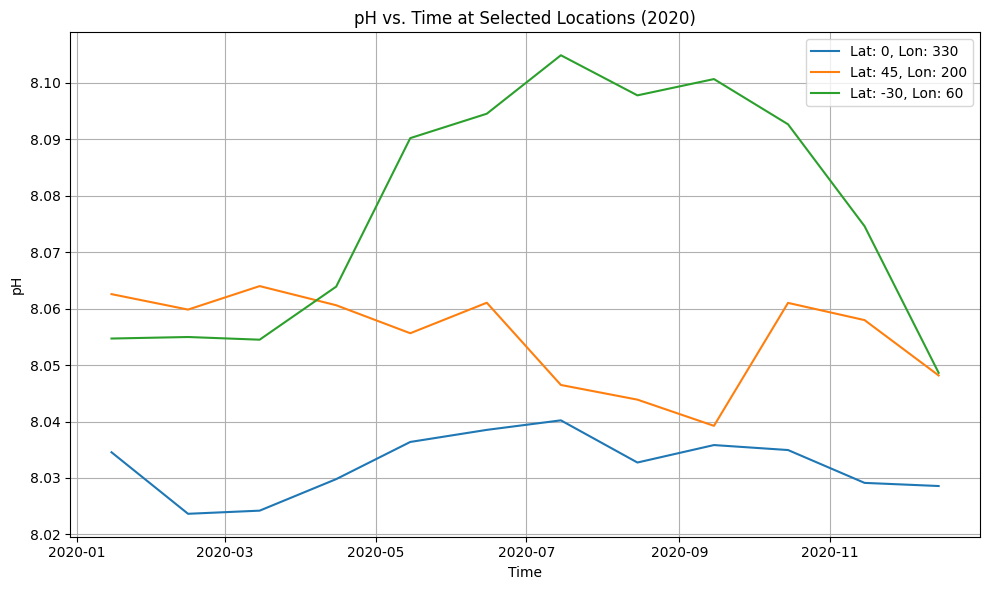

In [20]:
# Define points (in degrees East for longitude)
points = [
    {"lat": 0, "lon": 330},      # near the equator, Atlantic
    {"lat": 45, "lon": 200},     # North Pacific
    {"lat": -30, "lon": 60},     # South Indian Ocean
]

# Create the plot
plt.figure(figsize=(10, 6))

for point in points:
    # Select pH at the nearest grid point
    pH_point = ds_pH['ph'].sel(latitude=point["lat"], longitude=point["lon"], method="nearest")
    plt.plot(ds_pH['time'], pH_point,label=f"Lat: {point['lat']}, Lon: {point['lon']}")

plt.xlabel("Time")
plt.ylabel("pH")
plt.title("pH vs. Time at Selected Locations (2020)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()